# Individuell uppgift - Hälsostudie

---

## Introduktion

Jag, en fiktiv dataanalytiker på ett forskningsinstitut, Fejk Forskning<sup>™</sup>, har fått i uppdrag att analysera data från en hälsostudie som institutet har bedrivit. 

Studien har sammanställt 800 deltagares ålder, kön, vikt, längd, blodtryck, kolesterolnivå, rökvanor och om de har en viss sjukdom. 

Mitt uppdrag är att undersöka relationen mellan blodtryck och rökning, blodtryck och ålder, och sjukdomsförekomst per kön. 

Uppgiften är indelad i två delar: Del 1 Grundläggande analys och statistik och Del 2 Fördjupning och pipeline. 

Allt arbete presenteras i den här rapporten.

---







## Dataförberedelse och "Rengöring"

In [126]:
"""Importera paket"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

"""Importera data"""

df = pd.read_csv("data/health_study_dataset.csv")

Det första jag gör att att importera de paket jag vet kommer behövas i det här arbetet. 
Jag väljer att ge paketen kortare namn för att de ska vara smidigare att använda. 

csv-filen läses in som en DataFrame i variabeln df. 

### Få en första överblick av datasetet

In [127]:
"""Kolla kolumner och struktur"""

df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


In [128]:
"""Kolla Dtype"""

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [129]:
"""Kolla antalet NaN i varje kolumn"""

df.isna().sum()

id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64

In [130]:
"""Kolla antalet dubletter"""

print(f"Antal dubletter: {df.duplicated().sum()}")

Antal dubletter: 0


För att få grepp om hur komplett - eller icke-komplett - datan är anväder jag mig av följande funktioner: 

* .head()
* .info()
* .isna()
* .duplicated()

Jag konstaterar att det inte saknas några värden och att det heller inte finns några dubletter. 

Den enda anmärkningen jag har är att kolumnerna "smoker" och "sex" har fel Dtype. 

Kolumnerna är skapade med Dtype "object" vilket strängar ofta blir, men enligt pandas dokumentationen är det bättre att använda Dtype "category" när: 

* Det är strängar med bara några få värden. Som i det här fallet: F eller M och Yes eller No 
* Man ska använda datan i analys eller när man ska visuallisera den

Källa: https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html

Jag väljer därför att ändra från "object" till "category". Se nedan: 


### Ändra Dtypes

In [131]:
"""Ändra från object till category för kolumnerna sex och disease"""

df["smoker"] = df["smoker"].astype("category")
df["sex"] = df["sex"].astype("category")

## Beskrivande analys

### Sammanställning av nyckeltal

In [132]:
"""
Beräkning av min, max, medel och median
för age, height, weight, systolic_bp och cholesterol
"""

stats = (
    df[["age", "height", "weight", "systolic_bp", "cholesterol"]]
    .describe()
    .round(1)
    .loc[["min", "max", "mean", "50%"]]
    .rename(index={"50%": "median"})
)
print(stats)

         age  height  weight  systolic_bp  cholesterol
min     18.0   144.4    33.7        106.8          2.5
max     90.0   200.4   114.4        185.9          7.9
mean    49.4   171.8    73.4        149.2          4.9
median  50.0   171.4    73.2        149.4          5.0


Jag väljer att använda funktionen .describe() på min DataFrame för att snabbt och lätt räkna ut min, max, medel och median. 

.describe() utan "filter" visar alla kolumner som finns med i df:en, men jag ville bara ha med vissa av kolumnerna. 

M.h.a. inre brackets gör man först en lista över de kolumner som ska vara med. Sen plockas datan ut från df:en m.h.a. de yttre klamrarna. 

(https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)

.describe() ger också ett antal rader till som inte var relevanta för den här presentationen. Att välja ut de rader (eller index) som ska vara med fungerar typ som på samma sätt som med att välja ut kolumner.

Men man måste specificera att det är "x-axeln" i DataFram:en och inte "y-axeln". Detta görs med .loc. 

(https://pandas.pydata.org/docs/user_guide/indexing.html) 

Namnet på raden/index för median som kommer automatisk med funktionen .describe() är "50%", men det är lite svårt att förstå tycker jag så jag valde att ändra namnet till "median". 

Detta gjorde jag med funktionen .rename() som byter namn på etiketter i en DataFrame. Med "index" specificerar man att det är en radetikett som ska ändras. 

(Motsvarande för en kolumn hade varit "columns")

(https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html)

Och sist men inte minst så valde jag att avrunda alla värden till en decimal med .round(1). 

Jag valde en decimal för att ursprungsdatan inte är mer precis än så. 

### Explorativ Dataanalys (EDA)

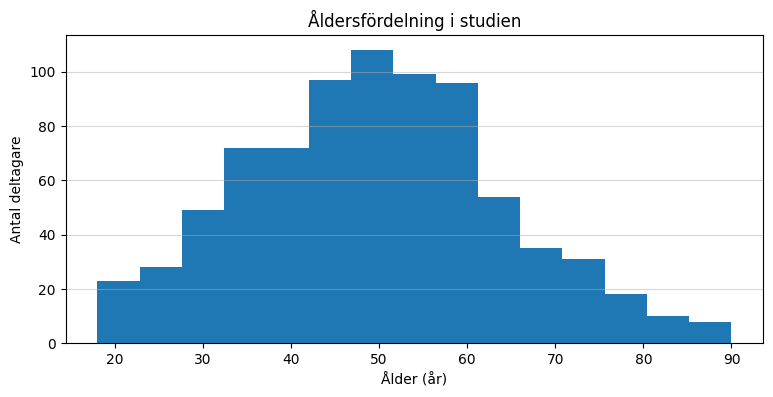

In [133]:
"""Skapa Histogram för ålder"""

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["age"], bins=15)
ax.set_title("Åldersfördelning i studien")
ax.set_xlabel("Ålder (år)")
ax.set_ylabel("Antal deltagare")
ax.grid(axis="y", alpha=0.5)

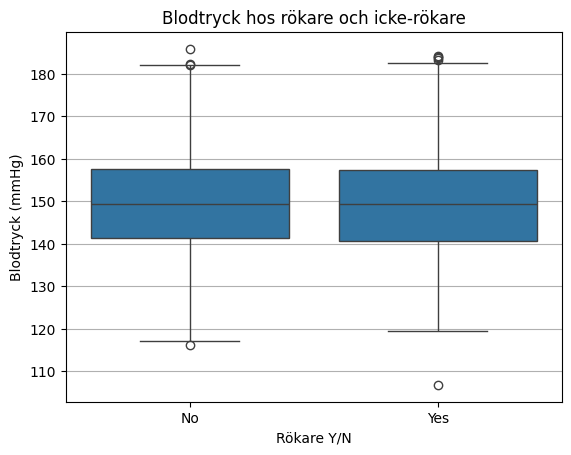

In [134]:
"""Boxplot, Blodtryck: Rökare vs Icke-rökare """

ax = sns.boxplot(df, x="smoker", y="systolic_bp")
ax.set(
    xlabel= "Rökare Y/N",
    ylabel= "Blodtryck (mmHg)",
    title= "Blodtryck hos rökare och icke-rökare"
)
ax.grid(True, axis="y")
plt.show()

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html --- att hålla på med arrayers och listor osv fick mig att kolla efter enklare sätt:

https://www.geeksforgeeks.org/python/how-to-create-boxplots-by-group-in-matplotlib/ --- hamnade här och upptäckte att seaborn gör det enklare

Skriv kort om seaborn 

https://seaborn.pydata.org/faq.html -- hittade svar på hur man ger plotten titles, hur man får bort texten som kommer med (plt.show()) vilket fungerar på samma sätt som med matplotlib så jag testade att lägga till grid på "det gamla sättet" och det fungerade ju! 

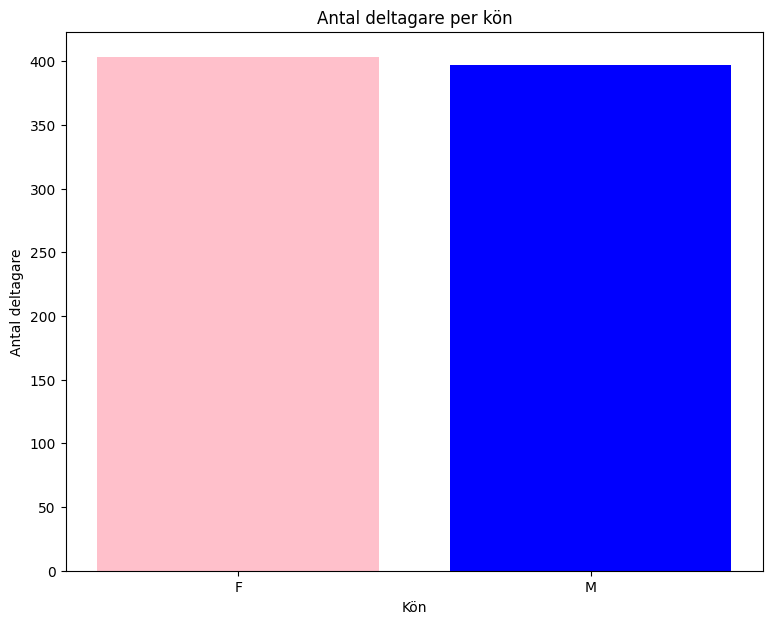

In [135]:
"""Stapeldiagram över antalet kvinnor och män"""

num_women_men = df["sex"].value_counts()

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_women_men.index, num_women_men.values, color=["pink", "blue"])
ax.set(
    title = "Antal deltagare per kön",
    xlabel = "Kön",
    ylabel = "Antal deltagare",
)
plt.show()

En bar chart behöver ett x och en height (y)

Och problemet är att vi vill plocka ut F och M från kolumnen sex och stoppa in detta på x 

Och att vi vid sidan av behöver räkan ut antalet män och kvinnor 

Som vi sedan på något vänster behöver stoppa in på height 

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html?utm_source=chatgpt.com

https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.values.html

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.index.html




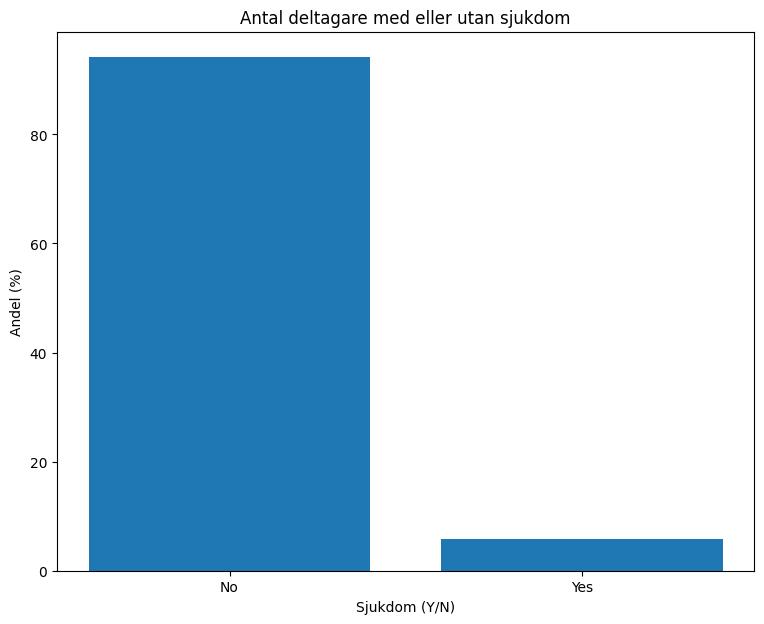

In [150]:
"""Stapeldiagram över andelen med sjukdom"""

num_disease = df["disease"].value_counts(normalize=True).round(4).rename(index={0: "No", 1: "Yes"}) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_disease.index, num_disease.values)
ax.set(
    title = "Antal deltagare med eller utan sjukdom",
    xlabel = "Sjukdom (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

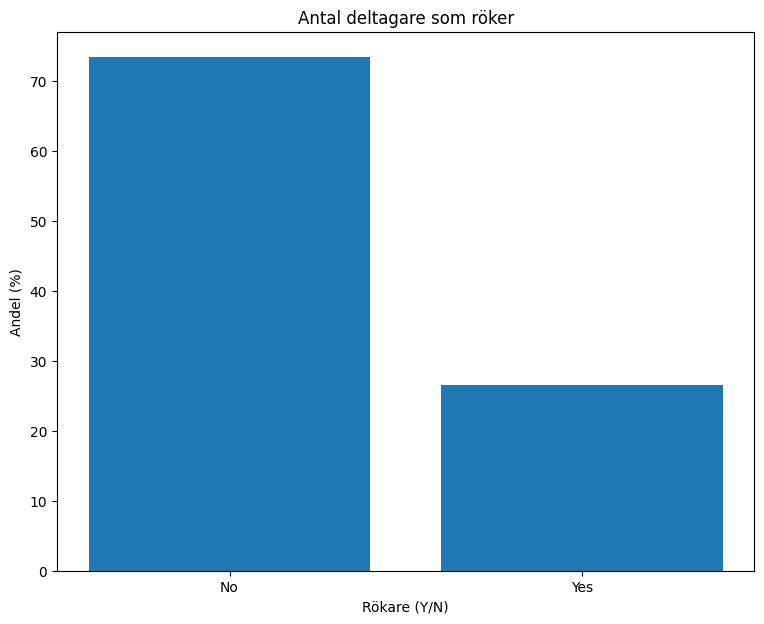

In [155]:
"""Stapeldiagram över andelen rökare"""

num_smoker = df["smoker"].value_counts(normalize=True).round(4) * 100

fig, ax = plt.subplots(figsize=(9, 7))
ax.bar(num_smoker.index, num_smoker.values)
ax.set(
    title = "Antal deltagare som röker",
    xlabel = "Rökare (Y/N)",
    ylabel = "Andel (%)",
)
plt.show()

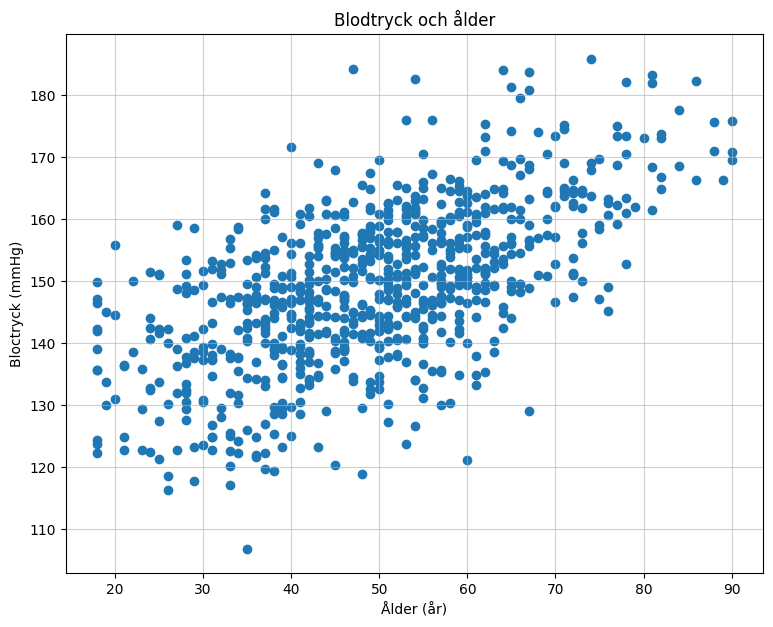

In [164]:
"""Scatterplot, blodtryck vs ålder"""

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df["age"], df["systolic_bp"])
ax.set(
    title = "Blodtryck och ålder",
    xlabel = "Ålder (år)",
    ylabel = "Bloctryck (mmHg)",
)
ax.grid(True, alpha=0.6)
plt.show()

https://www.statology.org/which-variable-x-axis-y-axis/

## Simulering kopplad till caset

## Konfidensintervall

### Normalapproximation

### Bootstrap

## Hypotesprövning

## Statistical Power